In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb


In [3]:
sb.set()

cardio = pd.read_csv('cardio_train.csv', sep=';')

cardio.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
cardio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:

cardio_clean = cardio.copy()


cardio_clean.columns = cardio_clean.columns.str.upper()


cardio_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           70000 non-null  int64  
 1   AGE          70000 non-null  int64  
 2   GENDER       70000 non-null  int64  
 3   HEIGHT       70000 non-null  int64  
 4   WEIGHT       70000 non-null  float64
 5   AP_HI        70000 non-null  int64  
 6   AP_LO        70000 non-null  int64  
 7   CHOLESTEROL  70000 non-null  int64  
 8   GLUC         70000 non-null  int64  
 9   SMOKE        70000 non-null  int64  
 10  ALCO         70000 non-null  int64  
 11  ACTIVE       70000 non-null  int64  
 12  CARDIO       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
dupid_data_clean = cardio_clean[cardio_clean.duplicated("ID", keep = False)]
print("Titles with Duplicate IDs :", len(dupid_data_clean))
cardio_clean.isnull().sum()

Titles with Duplicate IDs : 0


ID             0
AGE            0
GENDER         0
HEIGHT         0
WEIGHT         0
AP_HI          0
AP_LO          0
CHOLESTEROL    0
GLUC           0
SMOKE          0
ALCO           0
ACTIVE         0
CARDIO         0
dtype: int64

In [7]:
#Differentiate whether a varible is a numerical or categorical data type
cardio_clean['GENDER'] = cardio_clean['GENDER'].astype('category')
cardio_clean['CHOLESTEROL'] = cardio_clean['CHOLESTEROL'].astype('category')
cardio_clean['GLUC'] = cardio_clean['GLUC'].astype('category')
cardio_clean['SMOKE'] = cardio_clean['SMOKE'].astype('category')
cardio_clean['ALCO'] = cardio_clean['ALCO'].astype('category')
cardio_clean['ACTIVE'] = cardio_clean['ACTIVE'].astype('category')
cardio_clean['CARDIO'] = cardio_clean['CARDIO'].astype('category')

#Print the Variable Information to check
cardio_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   ID           70000 non-null  int64   
 1   AGE          70000 non-null  int64   
 2   GENDER       70000 non-null  category
 3   HEIGHT       70000 non-null  int64   
 4   WEIGHT       70000 non-null  float64 
 5   AP_HI        70000 non-null  int64   
 6   AP_LO        70000 non-null  int64   
 7   CHOLESTEROL  70000 non-null  category
 8   GLUC         70000 non-null  category
 9   SMOKE        70000 non-null  category
 10  ALCO         70000 non-null  category
 11  ACTIVE       70000 non-null  category
 12  CARDIO       70000 non-null  category
dtypes: category(7), float64(1), int64(5)
memory usage: 3.7 MB


In [8]:
#Create a new column in the dataframe 'AGE_YEARS' to convert the age of patients from days into years for easier reading
cardio_clean['AGE_YEARS'] = cardio_clean['AGE']/365

#Convert Variable 'AGE_YEARS' from float to integer data type
cardio_clean['AGE_YEARS'] = cardio_clean['AGE_YEARS'].astype('int64')

#Print the Variable Information to check
cardio_clean.head()

,ID,AGE,GENDER,HEIGHT,WEIGHT,AP_HI,AP_LO,CHOLESTEROL,GLUC,SMOKE,ALCO,ACTIVE,CARDIO,AGE_YEARS
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47


In [9]:
import matplotlib.pyplot as plt
import seaborn as sb

In [32]:
# convert age from days to years
df['age_years'] = df['age'] / 365

# create BMI
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

# create age groups
df['age_group'] = pd.cut(
    df['age_years'],
    bins=[0, 40, 50, 60, 70, 100],
    labels=['<40', '40-50', '50-60', '60-70', '70+']
)

df[['age_years', 'bmi', 'age_group']].head()

,age_years,bmi,age_group
0,50.391781,21.967120,50-60
1,55.419178,34.927679,50-60
2,51.663014,23.507805,50-60
3,48.282192,28.710479,40-50
4,47.873973,23.011177,40-50


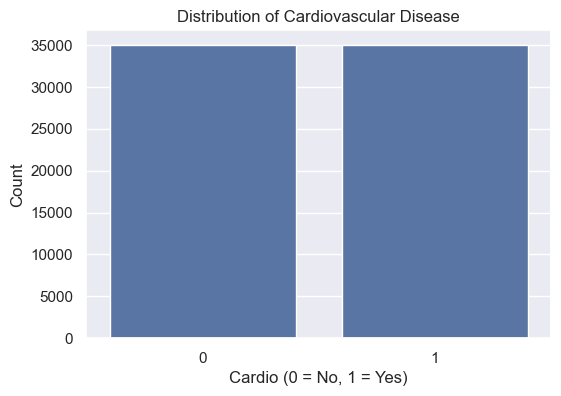

In [24]:
plt.figure(figsize=(6,4))
sb.countplot(x='cardio', data=df)

plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardio (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

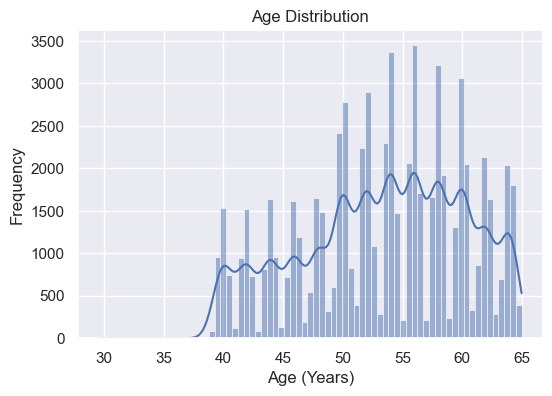

In [33]:
plt.figure(figsize=(6,4))
sb.histplot(df['age_years'], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")

plt.show()

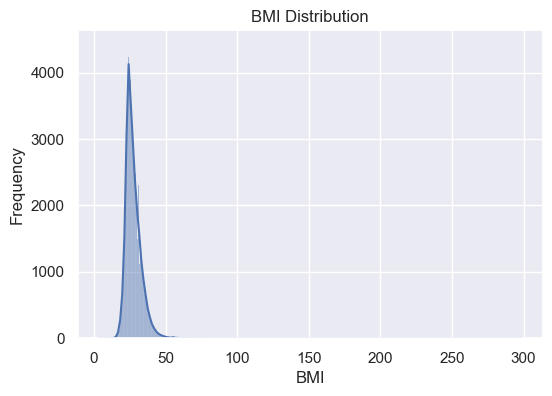

In [34]:
plt.figure(figsize=(6,4))
sb.histplot(df['bmi'], kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

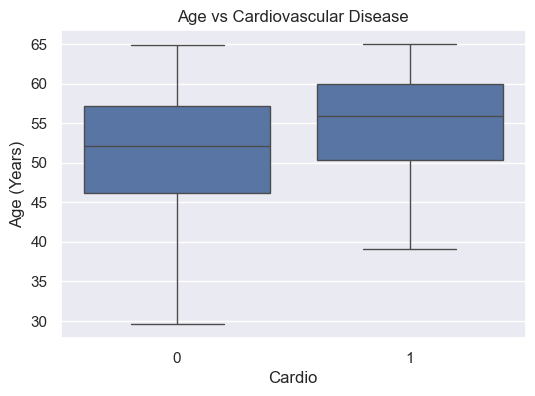

In [35]:
plt.figure(figsize=(6,4))
sb.boxplot(x='cardio', y='age_years', data=df)

plt.title("Age vs Cardiovascular Disease")
plt.xlabel("Cardio")
plt.ylabel("Age (Years)")

plt.show()

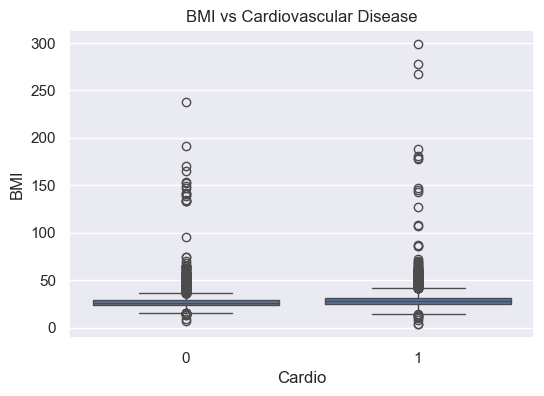

In [36]:
plt.figure(figsize=(6,4))
sb.boxplot(x='cardio', y='bmi', data=df)

plt.title("BMI vs Cardiovascular Disease")
plt.xlabel("Cardio")
plt.ylabel("BMI")

plt.show()

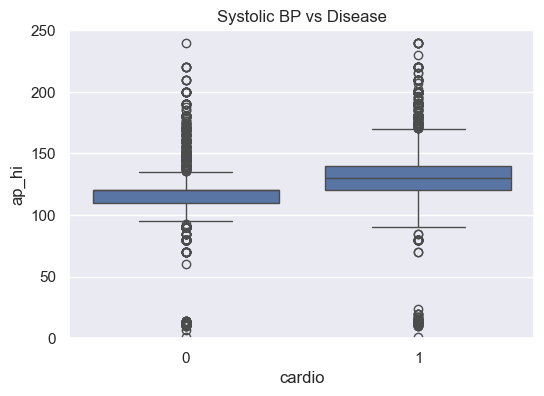

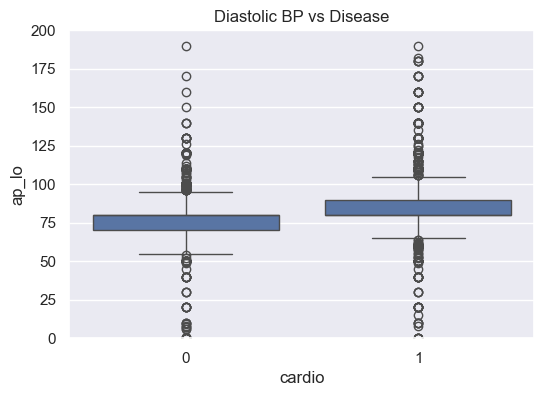

In [37]:
plt.figure(figsize=(6,4))
sb.boxplot(x='cardio', y='ap_hi', data=df)

plt.title("Systolic BP vs Disease")
plt.ylim(0,250)

plt.show()

plt.figure(figsize=(6,4))
sb.boxplot(x='cardio', y='ap_lo', data=df)

plt.title("Diastolic BP vs Disease")
plt.ylim(0,200)

plt.show()

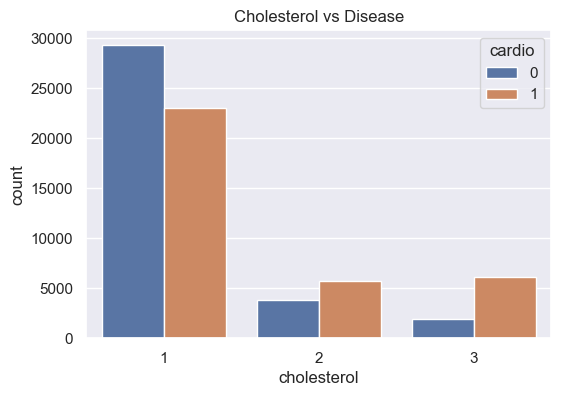

In [38]:
plt.figure(figsize=(6,4))
sb.countplot(x='cholesterol', hue='cardio', data=df)

plt.title("Cholesterol vs Disease")

plt.show()

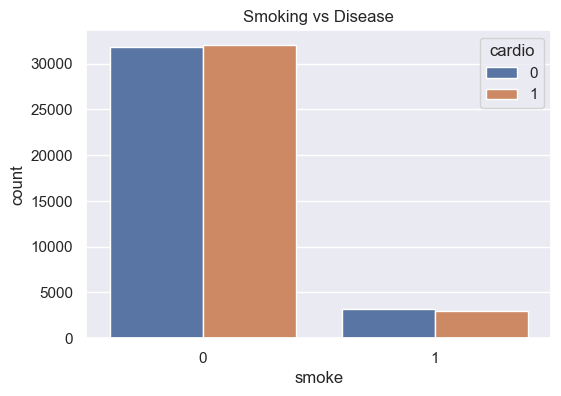

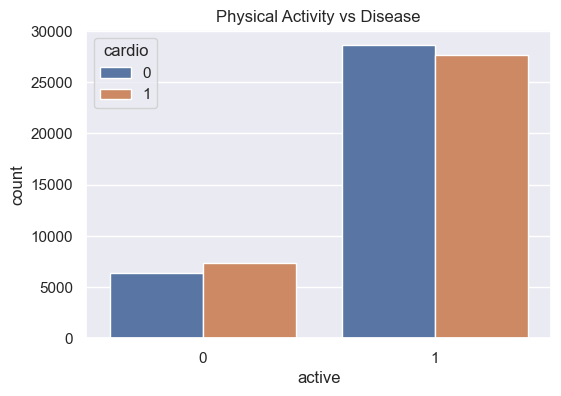

In [39]:
plt.figure(figsize=(6,4))
sb.countplot(x='smoke', hue='cardio', data=df)

plt.title("Smoking vs Disease")
plt.show()

plt.figure(figsize=(6,4))
sb.countplot(x='active', hue='cardio', data=df)

plt.title("Physical Activity vs Disease")
plt.show()

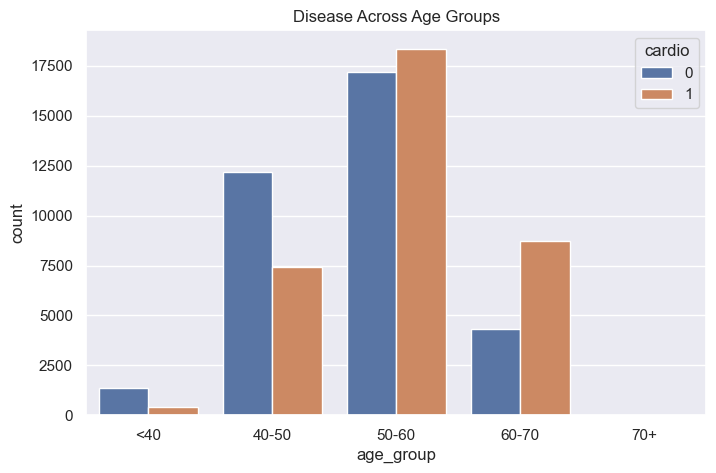

In [40]:
plt.figure(figsize=(8,5))
sb.countplot(x='age_group', hue='cardio', data=df)

plt.title("Disease Across Age Groups")

plt.show()

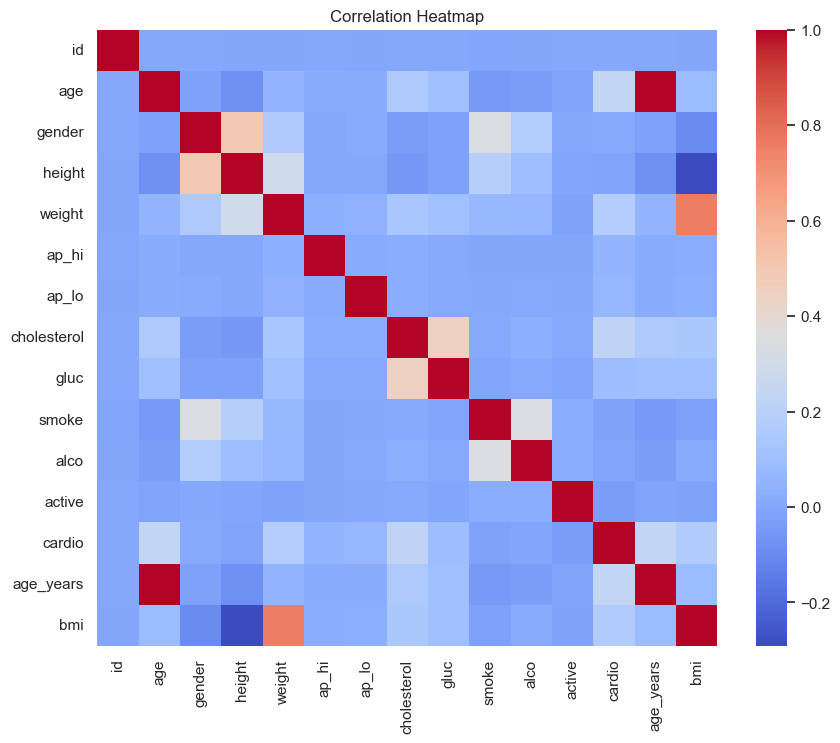

In [43]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sb.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)

plt.title("Correlation Heatmap")

plt.show()

In [44]:
features = ['age_years','bmi','ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']

df[features + ['cardio']].corr()['cardio'].sort_values(ascending=False)

cardio         1.000000
age_years      0.238159
cholesterol    0.221147
bmi            0.165632
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
alco          -0.007330
smoke         -0.015486
active        -0.035653
Name: cardio, dtype: float64

In [45]:
clinical = ['ap_hi','ap_lo','cholesterol','gluc']
non_clinical = ['age_years','bmi','smoke','alco','active']

print("Clinical correlation:")
print(df[clinical + ['cardio']].corr()['cardio'].sort_values(ascending=False))

print("\nNon-clinical correlation:")
print(df[non_clinical + ['cardio']].corr()['cardio'].sort_values(ascending=False))

Clinical correlation:
cardio         1.000000
cholesterol    0.221147
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
Name: cardio, dtype: float64

Non-clinical correlation:
cardio       1.000000
age_years    0.238159
bmi          0.165632
alco        -0.007330
smoke       -0.015486
active      -0.035653
Name: cardio, dtype: float64
